# Практикум: строим векторную модель для контент-анализа Telegram 

## Шаг 1: выгрузка данных из Telegram-канала 

- извлекаем тексты из Telegram-канала
- сохраняем тексты в формате 'txt' 

In [1]:
import json

# Загрузка данных
with open("result.json", "r", encoding = "utf-8") as f:
    data = json.load(f)

messages = []

for elem in data["messages"]:
    if type(elem) == dict:
        if type(elem["text"]) == list:
            message = ''
            for el in elem["text"]:
                if type(el) == str:
                    message += el
                else:
                    message += el["text"]
            messages.append(message)
    if type(elem) == str:
        messages.append(elem)


print(messages)

['Сегодня особенно хочется верховных уютов и красивых вещей. Поэтому собрала на фристайле подборку на Lamoda из разного. Что нашла по приятным ценам:\n\nчерное постельное белье — 5232₽\nнабор тарелок — 4266₽\nваза — 2232₽\nподсвечники — 2366₽\nкружка — 490₽\nсвеча — 2976₽\nподсвечник — 1606₽\nтарелка — 2260₽\nнабор бокалов — 2792₽', 'Смотрим на новинки моего любимого бренда D’heygere. Обожаю их за то, что каждый предмет мемнее другого. Чего стоит, например, кольцо в виде коробки с кольцом. Или серьги-ногти. Сразу говорю, что такое нужно уметь носить и если вы серьезно относитесь к себе, то вам не понравится. Для понимания и наглядности принесла Анастасию Миронову в их серьгах в виде дверных ручек. Тот самый случай, когда человек идеально чувствует. А не бездумно употребляет очередную «модную» придумку очередного бренда', 'Вопрос снят после прочтения этого поста Иры. Она арт-директор и режиссер в Befree, а значит точно шарит. Беру лайфхак в работу и вам искренне советую!', 'Так выглядит

In [2]:
with open("data.txt", "w", encoding = "utf-8") as f:
    f.writelines(messages)

## Шаг 2: запись текста в переменную и разделение на чанки

In [3]:
with open("data.txt", "r", encoding = "utf-8") as f:
    texts = f.read()

In [4]:
texts

'Сегодня особенно хочется верховных уютов и красивых вещей. Поэтому собрала на фристайле подборку на Lamoda из разного. Что нашла по приятным ценам:\n\nчерное постельное белье — 5232₽\nнабор тарелок — 4266₽\nваза — 2232₽\nподсвечники — 2366₽\nкружка — 490₽\nсвеча — 2976₽\nподсвечник — 1606₽\nтарелка — 2260₽\nнабор бокалов — 2792₽Смотрим на новинки моего любимого бренда D’heygere. Обожаю их за то, что каждый предмет мемнее другого. Чего стоит, например, кольцо в виде коробки с кольцом. Или серьги-ногти. Сразу говорю, что такое нужно уметь носить и если вы серьезно относитесь к себе, то вам не понравится. Для понимания и наглядности принесла Анастасию Миронову в их серьгах в виде дверных ручек. Тот самый случай, когда человек идеально чувствует. А не бездумно употребляет очередную «модную» придумку очередного брендаВопрос снят после прочтения этого поста Иры. Она арт-директор и режиссер в Befree, а значит точно шарит. Беру лайфхак в работу и вам искренне советую!Так выглядит ballerina ca

Далее - разделение текста на **чанки**. 
Будет использоваться инструмент "рекурсивный сплитер". Этот инструмент создан на основе статистических алгоритмов и построен так, чтобы делить весь текст с учетом особенностей *синтаксиса*. В его основе - рекурсивный алгоритм, который вычисляет повторяющиеся (рекурсивные) паттерны, т.е. закономерности, в тексте.

In [5]:
# !pip install langchain

from langchain.text_splitter import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1000,
    chunk_overlap = 100
)

chunks = text_splitter.split_text(texts)

for i, chunk in enumerate(chunks):
    print(f"Chunk {i+1}:\n{chunk}\n")

Chunk 1:
Сегодня особенно хочется верховных уютов и красивых вещей. Поэтому собрала на фристайле подборку на Lamoda из разного. Что нашла по приятным ценам:

Chunk 2:
черное постельное белье — 5232₽
набор тарелок — 4266₽
ваза — 2232₽
подсвечники — 2366₽
кружка — 490₽
свеча — 2976₽
подсвечник — 1606₽
тарелка — 2260₽
набор бокалов — 2792₽Смотрим на новинки моего любимого бренда D’heygere. Обожаю их за то, что каждый предмет мемнее другого. Чего стоит, например, кольцо в виде коробки с кольцом. Или серьги-ногти. Сразу говорю, что такое нужно уметь носить и если вы серьезно относитесь к себе, то вам не понравится. Для понимания и наглядности принесла Анастасию Миронову в их серьгах в виде дверных ручек. Тот самый случай, когда человек идеально чувствует. А не бездумно употребляет очередную «модную» придумку очередного брендаВопрос снят после прочтения этого поста Иры. Она арт-директор и режиссер в Befree, а значит точно шарит. Беру лайфхак в работу и вам искренне советую!Так выглядит balle

In [6]:
print(f"Chunk {1}: \n{chunks[0]}\n")
print(len(f"Chunk {1}: \n{chunks[0]}\n"))

Chunk 1: 
Сегодня особенно хочется верховных уютов и красивых вещей. Поэтому собрала на фристайле подборку на Lamoda из разного. Что нашла по приятным ценам:

158


## Шаг 3: токенизация

In [7]:
import re

Напишем функцию для чистки текста, которая:
- приведёт текст к нижнему регистру
- удалит все символы кроме букв
- удалит двойные пробелы

In [8]:
with open("data.txt", "r", encoding = "utf-8") as f:
    texts = f.readlines()

def clean_text(texts):
    cleaned = []
    for text in texts:
        text = text.lower()
        text = re.sub('[^а-яa-z0-9\s]', '', text)
        text = re.sub(r'\n\n', ' ', text).strip()              
        cleaned.append(text)
    return cleaned

clean_text(texts)

['сегодня особенно хочется верховных уютов и красивых вещей поэтому собрала на фристайле подборку на lamoda из разного что нашла по приятным ценам',
 '',
 'черное постельное белье  5232',
 'набор тарелок  4266',
 'ваза  2232',
 'подсвечники  2366',
 'кружка  490',
 'свеча  2976',
 'подсвечник  1606',
 'тарелка  2260',
 'набор бокалов  2792смотрим на новинки моего любимого бренда dheygere обожаю их за то что каждый предмет мемнее другого чего стоит например кольцо в виде коробки с кольцом или серьгиногти сразу говорю что такое нужно уметь носить и если вы серьезно относитесь к себе то вам не понравится для понимания и наглядности принесла анастасию миронову в их серьгах в виде дверных ручек тот самый случай когда человек идеально чувствует а не бездумно употребляет очередную модную придумку очередного брендавопрос снят после прочтения этого поста иры она артдиректор и режиссер в befree а значит точно шарит беру лайфхак в работу и вам искренне советуютак выглядит ballerina cappuccino кур

Применяем функцию очистки текста к чанкам:

In [9]:
new_chunks = []
for chunk in chunks:
    cleaned = clean_text([chunk])
    new_chunks.append(cleaned[0])

for i, chunk in enumerate(new_chunks):
    print(f"Chunk {i+1}:\n{chunk}\n{'-'*40}")

Chunk 1:
сегодня особенно хочется верховных уютов и красивых вещей поэтому собрала на фристайле подборку на lamoda из разного что нашла по приятным ценам
----------------------------------------
Chunk 2:
черное постельное белье  5232
набор тарелок  4266
ваза  2232
подсвечники  2366
кружка  490
свеча  2976
подсвечник  1606
тарелка  2260
набор бокалов  2792смотрим на новинки моего любимого бренда dheygere обожаю их за то что каждый предмет мемнее другого чего стоит например кольцо в виде коробки с кольцом или серьгиногти сразу говорю что такое нужно уметь носить и если вы серьезно относитесь к себе то вам не понравится для понимания и наглядности принесла анастасию миронову в их серьгах в виде дверных ручек тот самый случай когда человек идеально чувствует а не бездумно употребляет очередную модную придумку очередного брендавопрос снят после прочтения этого поста иры она артдиректор и режиссер в befree а значит точно шарит беру лайфхак в работу и вам искренне советуютак выглядит ballerin

Применяем токенизацию:

In [10]:
finals = []

for chunk in new_chunks:
    tokenized = chunk.split()
    finals.append(tokenized)

for i, chunk in enumerate(finals):
    print(f'Chunk {i+1}:\n{chunk}\n{"-"*40}')

Chunk 1:
['сегодня', 'особенно', 'хочется', 'верховных', 'уютов', 'и', 'красивых', 'вещей', 'поэтому', 'собрала', 'на', 'фристайле', 'подборку', 'на', 'lamoda', 'из', 'разного', 'что', 'нашла', 'по', 'приятным', 'ценам']
----------------------------------------
Chunk 2:
['черное', 'постельное', 'белье', '5232', 'набор', 'тарелок', '4266', 'ваза', '2232', 'подсвечники', '2366', 'кружка', '490', 'свеча', '2976', 'подсвечник', '1606', 'тарелка', '2260', 'набор', 'бокалов', '2792смотрим', 'на', 'новинки', 'моего', 'любимого', 'бренда', 'dheygere', 'обожаю', 'их', 'за', 'то', 'что', 'каждый', 'предмет', 'мемнее', 'другого', 'чего', 'стоит', 'например', 'кольцо', 'в', 'виде', 'коробки', 'с', 'кольцом', 'или', 'серьгиногти', 'сразу', 'говорю', 'что', 'такое', 'нужно', 'уметь', 'носить', 'и', 'если', 'вы', 'серьезно', 'относитесь', 'к', 'себе', 'то', 'вам', 'не', 'понравится', 'для', 'понимания', 'и', 'наглядности', 'принесла', 'анастасию', 'миронову', 'в', 'их', 'серьгах', 'в', 'виде', 'дверн

## Шаг 4: строим модель Word2Vec

In [11]:
pip install gensim 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
from gensim.models import Word2Vec

# Обучение модели
model = Word2Vec(sentences=finals, vector_size=100, window=5, min_count=1, workers=4)

# Сохранение модели
model.save("word2vec.model")

**Gensim parameters:**

- sentences: this iterable can be simply a list of lists of tokens, but for larger corpora, consider an iterable that streams the sentences directly from disk/network. 
- vector_size: dimensionality of the word vectors.
- window: maximum distance between the current and predicted word within a sentence.
- min_count: ignores all words with total frequency lower than this.
- workers: use these many worker threads to train the model (=faster training with multicore machines).

In [13]:
# Загрузка модели
model = Word2Vec.load("word2vec.model")

# Получение вектора для слова
vector = model.wv["биоревитализация"]

# Нахождение похожих слов
similar_words = model.wv.most_similar("биоревитализация", topn=3)
print(similar_words)

[('фототерапия', 0.3233727216720581), ('удовольствия', 0.2380501627922058), ('забывали', 0.23140330612659454)]


Оценка векторной близости:

In [14]:
similarity = model.wv.similarity("фототерапия", "биоревитализация")
print(similarity)

0.3233727


In [15]:
model.wv['фототерапия']

array([ 7.4516726e-03, -6.1958181e-03,  9.9221552e-03, -7.4662962e-03,
        6.3694525e-03,  9.0769809e-03, -3.5829148e-03, -9.3896408e-03,
        2.3574641e-03,  1.2233575e-03, -8.0605829e-03, -7.1878708e-03,
       -4.6222247e-03, -7.5770880e-04, -8.0882488e-03, -3.9149332e-03,
       -2.2604505e-03, -7.0231064e-04,  6.6721053e-03,  5.7212124e-03,
        8.8793058e-03,  1.9007542e-03,  5.4827868e-03,  3.6245727e-03,
       -4.1391645e-03,  5.6763245e-03, -7.7239405e-03, -5.1581818e-03,
       -1.4010911e-03,  6.1070658e-03,  3.8938129e-03,  1.9559985e-04,
        1.1843274e-03,  8.4479265e-03,  1.4594112e-03,  4.3270280e-04,
       -7.7340882e-03, -6.1732084e-03,  1.4245950e-03, -2.6694618e-03,
        1.2195602e-03,  8.5433703e-03, -5.3185020e-03,  2.1418763e-04,
       -4.6991734e-03, -6.5841642e-03,  7.2855810e-03,  9.8839859e-03,
        7.5271172e-03, -6.0802428e-03,  9.4552934e-03, -9.6465265e-03,
       -1.3167947e-04, -2.9770983e-03,  2.3781059e-03,  6.3278140e-03,
      

**Умный вектор** - он же семантический вектор, вектор слова (**word embedding**)— это векторное представление слова, фразы или документа, которое содержит смысловую информацию. Обучается на огромных корпусах текстов и запоминает связи. 

Где применяются "умные" вектора?

- **Информационный поиск**: хранить информацию индекса удобнее в векторах, чтобы найти релевантный ответ в Google Search, достаточно "вытащить" из каталога наиболее близкий по вектору результат

- **Виртуальные ассистенты**: чат-боты на основе ИИ также используют эту технологию, чтобы дополнять свои ответы информацией из векторной базы знаний

- **Машинное обучение**: векторные представления создают перед машинным обучением, чтобы повысить качество классификации или моделирования языка

## Шаг 5: визуализация результатов

**PCA (principal component analysis)** - это статистическая модель, которая поможет нам вычислить из 100 чисел 2 самых важных и привести всю информацию к виду двухмерной матрицы

In [16]:
pip install matplotlib scikit-learn


  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ---------------------------------------- 0.0/108.7 kB ? eta -:--:--
     --- ------------------------------------ 10.2/108.7 kB ? eta -:--:--
     --- ------------------------------------ 10.2/108.7 kB ? eta -:--:--
     --- ------------------------------------ 10.2/108.7 kB ? eta -:--:--
     --- ------------------------------------ 10.2/108.7 kB ? eta -:--:--
     --- ------------------------------------ 10.2/108.7 kB ? eta -:--:--
     --- ------------------------------------ 10.2/108.7 kB ? eta -:--:--
     --- ------------------------------------ 10.2/108.7 kB ? eta -:--:--
     --- ------------------------------------ 10.2/108.7 kB ? eta -:--:--
     --- ------------------------------------ 10.2/108.7 kB ? eta -:--:--
     -------------- ----------------------- 41.0/108.7 kB 72.8 kB/s eta 0:00:01
     -------------- ----------------------- 41.0/108.7 kB 72.8 kB/s eta 0:00:01
     -------------- -----------------


[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


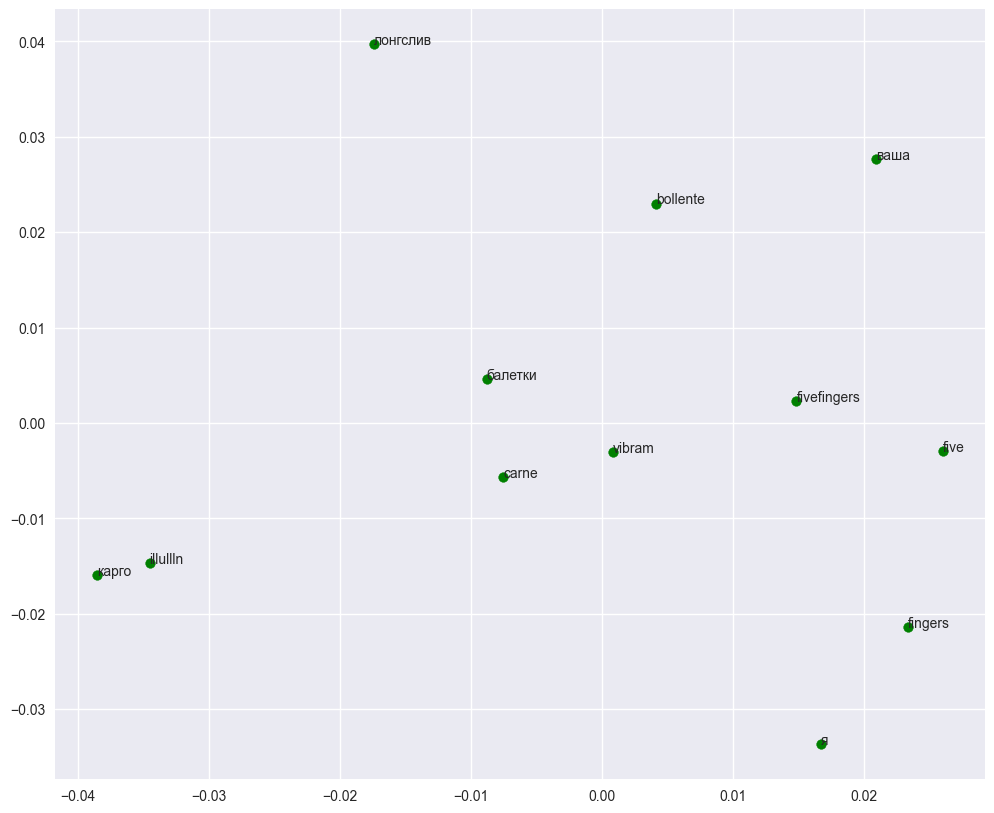

In [17]:
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')

# Модуль для построения PCA
from sklearn.decomposition import PCA

def pca_scatterplot(model, words=None, sample=0):
  word_vectors = [model.wv[w] for w in words]
  # Сокращаем размерность векторов до 2D
  vectors_2d = PCA().fit_transform(word_vectors)
  # Отрисовка изображения, задаем размер 12 на 10
  plt.figure(figsize=(12,10))
  # Задаем цвет точек и ссылаемся на данные по осям x (0) и y (1)
  plt.scatter(vectors_2d[:,0], vectors_2d[:,1], c='g')
  # Добавляем подписи к данным, проходимся по списку слов
  for i, word in enumerate(words):
    # Соотносим слово с его двухмерным вектором
    plt.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]))

# Картируем несколько слов
pca_scatterplot(model, ['лонгслив', 'illullln', 'карго', 'carne', 'bollente', 
                        'балетки', 'vibram', 'fivefingers', 'five', 
                        'fingers', 'ваша', 'я'])